In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

In [ ]:
data = yf.download("HDFCBANK.NS", start="2018-01-01")

if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

data.tail()

/tmp/ipykernel_1247/3879426083.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("HDFCBANK.NS", start="2018-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2026-03-09,840.700012,842.450012,821.500000,825.000000,35592613
2026-03-10,849.450012,856.799988,840.599976,850.049988,52866024
2026-03-11,833.950012,848.849976,827.599976,845.000000,42261076
2026-03-12,832.750000,836.400024,820.099976,820.099976,46107561
2026-03-13,817.000000,823.799988,812.000000,820.000000,41693319


In [ ]:
data["simple_return"] = data["Close"].pct_change()

data["log_return"] = np.log(data["Close"] / data["Close"].shift(1))

data = data.dropna()

data.head()

Price,Close,High,Low,Open,Volume,simple_return,log_return
Date,,,,,,,
2018-01-02,436.853760,437.472059,433.633982,433.633982,4776316,0.009625,0.009579
2018-01-03,432.257416,438.230362,431.919087,437.472077,4531288,-0.010521,-0.010577
2018-01-04,433.948975,435.255552,432.339072,432.339072,2373776,0.003913,0.003906
2018-01-05,434.812195,435.850479,432.933999,434.672209,2870868,0.001989,0.001987
2018-01-08,434.112274,436.468785,433.447322,435.138881,4570308,-0.001610,-0.001611


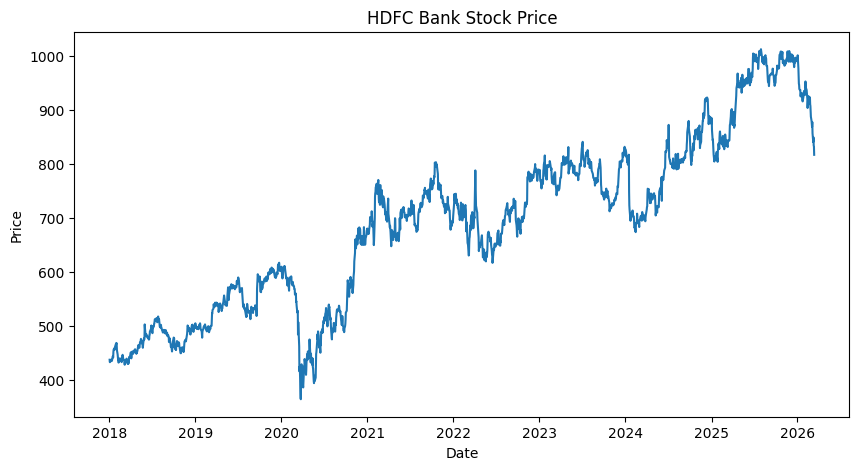

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(data.index, data["Close"])
plt.title("HDFC Bank Stock Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

## Volatility Analysis
Volatility measures how much the stock price fluctuates over time.
Higher volatility indicates higher investment risk.

In [ ]:
daily_volatility = data["log_return"].std()

annual_volatility = daily_volatility * np.sqrt(252)

print("Daily Volatility:", daily_volatility)
print("Annual Volatility:", annual_volatility)

Daily Volatility: 0.015079892357849267
Annual Volatility: 0.2393858698589556


## Sharpe Ratio
Sharpe Ratio measures the risk-adjusted return of the investment.
It compares excess return with the amount of risk taken.

In [ ]:
annual_return = data["log_return"].mean() * 252

risk_free_rate = 0.07

sharpe_ratio = (annual_return - risk_free_rate) / annual_volatility

print("Annual Return:", annual_return)
print("Sharpe Ratio:", sharpe_ratio)

Annual Return: 0.07909936289959192
Sharpe Ratio: 0.03801127821351023


## Beta Calculation (Market Risk)
Beta measures how sensitive the stock is compared to the overall market.

In [ ]:
market = yf.download("^NSEI", start="2018-01-01")

if isinstance(market.columns, pd.MultiIndex):
    market.columns = market.columns.get_level_values(0)

market["market_return"] = market["Close"].pct_change()

combined = pd.concat(
    [data["simple_return"], market["market_return"]],
    axis=1
)

combined.columns = ["stock", "market"]

combined = combined.dropna()

X = sm.add_constant(combined["market"])
y = combined["stock"]

model = sm.OLS(y, X).fit()

beta = model.params["market"]

print("Beta:", beta)

/tmp/ipykernel_1247/2279921138.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  market = yf.download("^NSEI", start="2018-01-01")
[*********************100%***********************]  1 of 1 completed

Beta: 1.038945160936965


## Value at Risk (VaR)
Value at Risk estimates the maximum expected loss over a specific time period at a given confidence level.

In [ ]:
VaR_95 = np.percentile(data["log_return"], 5)
print("95% Value at Risk:", VaR_95)

95% Value at Risk: -0.021407982921068717


## Stationarity Test (ADF)
The Augmented Dickey-Fuller test checks whether the time series is stationary.

In [ ]:
result = adfuller(data["log_return"])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -10.140937928615696
p-value: 8.424311421205427e-18


## ARIMA Model
ARIMA is used for time series forecasting.

In [ ]:
model = ARIMA(data["log_return"], order=(1,0,1))

model_fit = model.fit()

print(model_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:             log_return   No. Observations:                 2025
Model:                 ARIMA(1, 0, 1)   Log Likelihood                5621.455
Date:                Sat, 14 Mar 2026   AIC                         -11234.910
Time:                        11:27:59   BIC                         -11212.457
Sample:                             0   HQIC                        -11226.671
                               - 2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0003      0.000      0.893      0.372      -0.000       0.001
ar.L1         -0.0220      0.439     -0.050      0.960      -0.882       0.837
ma.L1          0.0459      0.438      0.105      0.9

## Forecast Future Returns

In [ ]:
forecast = model_fit.forecast(steps=5)

print("Next 5 day forecast:")
print(forecast)

Next 5 day forecast:
2025   -0.000151
2026    0.000322
2027    0.000311
2028    0.000312
2029    0.000312
Name: predicted_mean, dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


## Return Distribution
Visualizing the distribution of log returns.

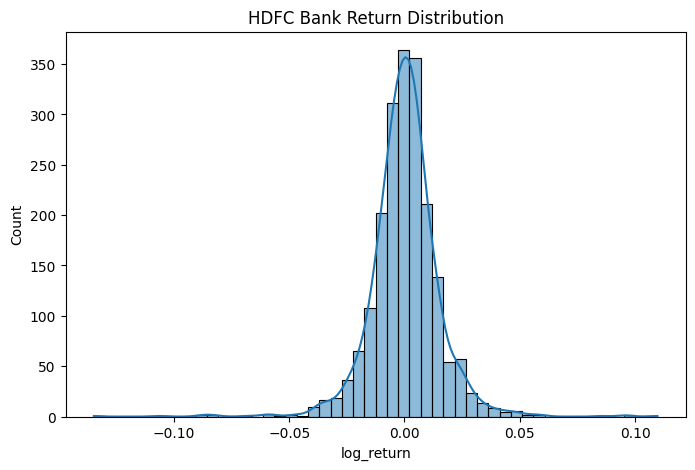

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(data["log_return"], bins=50, kde=True)

plt.title("HDFC Bank Return Distribution")

plt.show()

## Performance Analysis using Pyfolio
This section analyzes the performance of HDFC Bank stock compared to the market benchmark.

In [ ]:
!pip install pyfolio-reloaded

In [ ]:
import pyfolio as pf
import pandas as pd
import numpy as np
import yfinance as yf

/usr/local/lib/python3.12/dist-packages/pyfolio/pos.py:25: UserWarning: Module "zipline.assets" not found; multipliers will not be applied to position notionals.
  warnings.warn(


### Download Benchmark Data (NIFTY 50)

In [ ]:
market = yf.download("^NSEI", start="2018-01-01")

if isinstance(market.columns, pd.MultiIndex):
    market.columns = market.columns.get_level_values(0)
market.tail()

/tmp/ipykernel_1247/1414708894.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  market = yf.download("^NSEI", start="2018-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2026-03-09,24028.050781,24078.150391,23697.800781,23868.050781,526900
2026-03-10,24261.599609,24303.800781,24079.949219,24280.800781,444300
2026-03-11,23866.849609,24299.000000,23834.300781,24231.849609,407400
2026-03-12,23639.150391,23833.150391,23556.300781,23674.849609,501000
2026-03-13,23151.099609,23492.400391,23112.000000,23462.500000,0


### Compute Benchmark Returns

In [ ]:
market["market_return"] = np.log(
    market["Close"] / market["Close"].shift(1)
)

benchmark_returns = market["market_return"].dropna()
benchmark_returns.head()

,market_return
Date,
2018-01-03,0.000096
2018-01-04,0.005881
2018-01-05,0.005132
2018-01-08,0.006114
2018-01-09,0.001261


### Prepare Stock Returns

In [ ]:
returns = data["log_return"]

# remove timezone if present
returns.index = returns.index.tz_localize(None)
benchmark_returns.index = benchmark_returns.index.tz_localize(None)

### Generate Pyfolio Performance Report

The Pyfolio tear sheet provides a comprehensive summary of portfolio performance including:

- cumulative returns
- drawdown periods
- rolling Sharpe ratio
- volatility analysis
- return distribution

/usr/local/lib/python3.12/dist-packages/pyfolio/plotting.py:670: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '4.693%' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  perf_stats.loc[stat, column] = str(np.round(value * 100, 3)) + "%"


Start date,2018-01-03
End date,2026-03-13
Total months,96
,Backtest
Annual return,4.693%
Cumulative returns,44.426%
Annual volatility,23.959%
Sharpe ratio,0.31
Calmar ratio,0.11
Stability,0.68
Max drawdown,-42.682%


Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,42.68,2019-12-23,2020-03-24,2020-11-24,242
1,25.17,2021-10-19,2022-06-16,2023-07-04,446
2,20.91,2023-07-04,2024-02-14,2024-07-03,262
3,19.79,2025-07-30,2026-03-13,NaT,NaN
4,16.61,2021-02-16,2021-04-12,2021-10-14,173


/usr/local/lib/python3.12/dist-packages/pyfolio/plotting.py:1407: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Daily", "Weekly", "Monthly"])


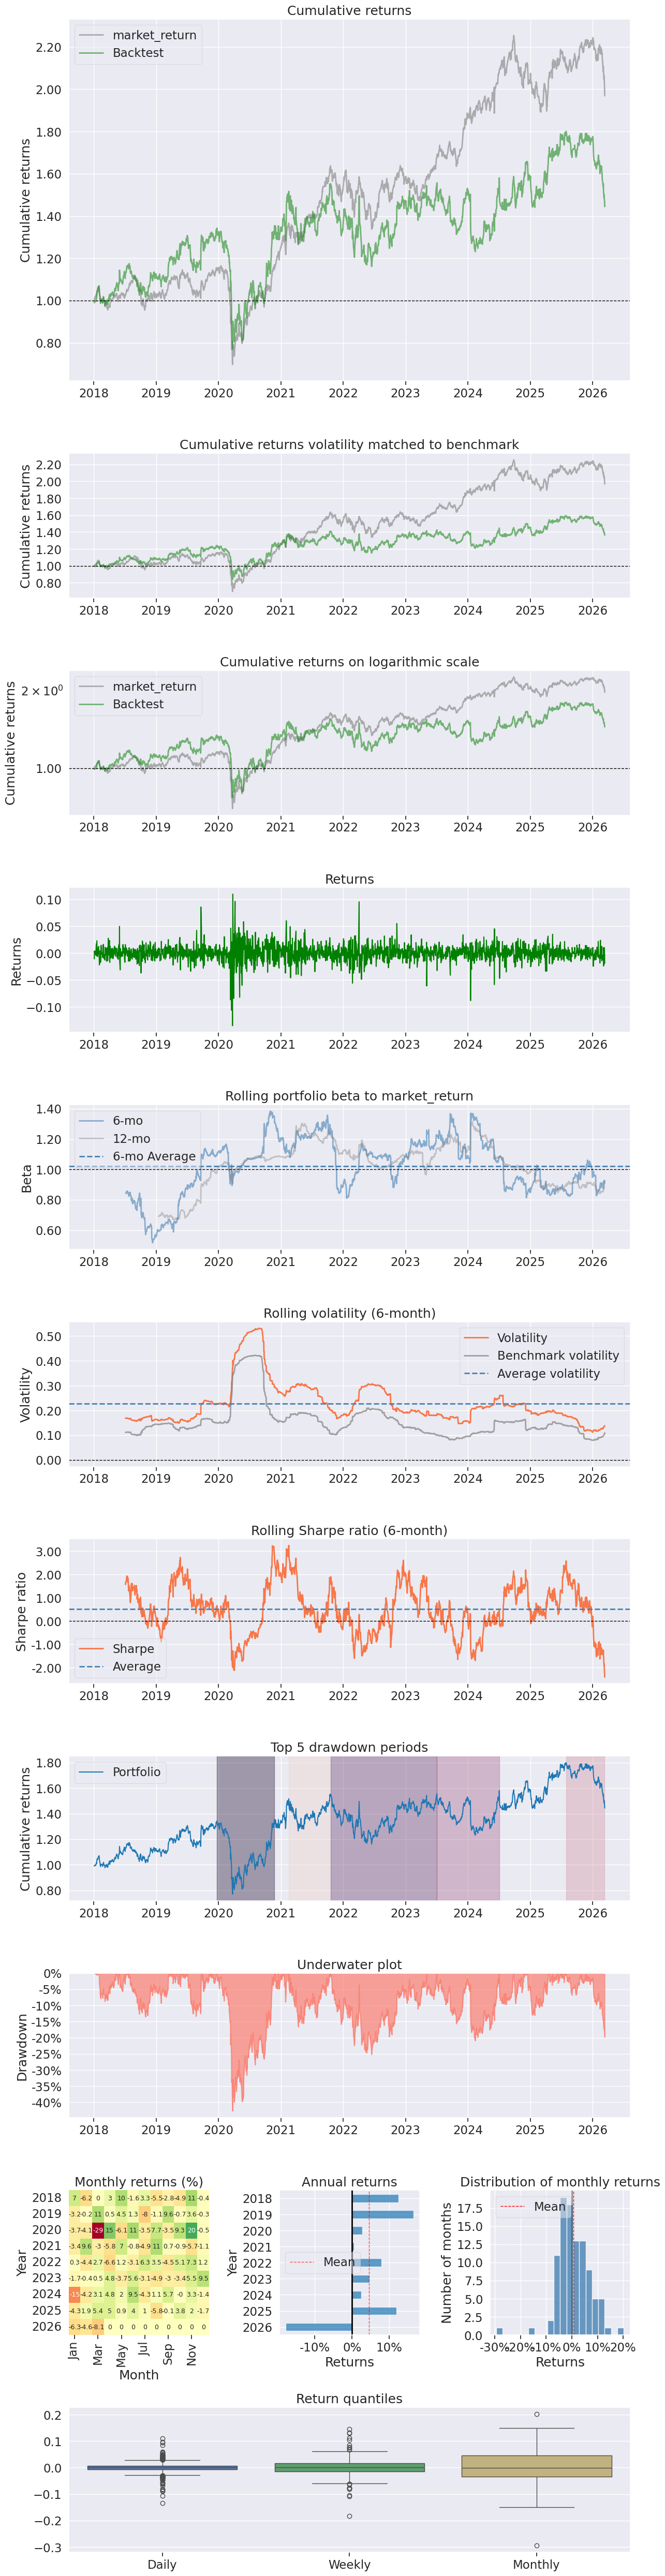

In [ ]:
pf.create_returns_tear_sheet(
    returns,
    benchmark_rets=benchmark_returns
)

### Rolling Volatility

Rolling volatility helps visualize how risk evolves over time.

<Axes: title={'center': 'Rolling volatility (6-month)'}, ylabel='Volatility'>

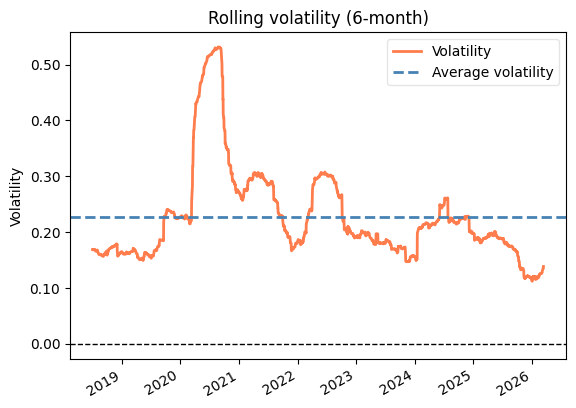

In [ ]:
pf.plotting.plot_rolling_volatility(returns)

### Rolling Sharpe Ratio

<Axes: title={'center': 'Rolling Sharpe ratio (6-month)'}, ylabel='Sharpe ratio'>

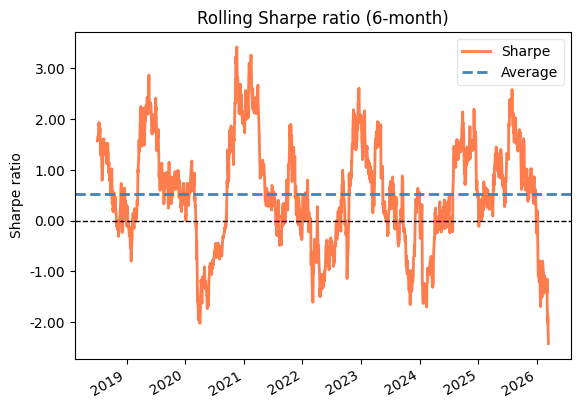

In [ ]:
pf.plotting.plot_rolling_sharpe(returns)

### Drawdown Analysis

Drawdown represents the decline from a historical peak.

This helps identify periods of large losses.

<Axes: title={'center': 'Top 10 drawdown periods'}, ylabel='Cumulative returns'>

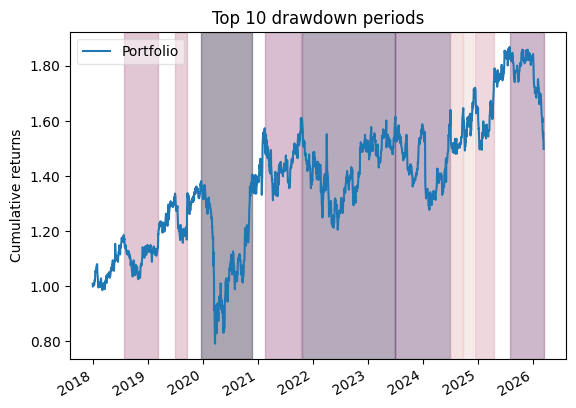

In [ ]:
pf.plotting.plot_drawdown_periods(returns)

## Rolling Metrics

Rolling volatility helps understand how the risk of HDFC Bank stock changes over time.

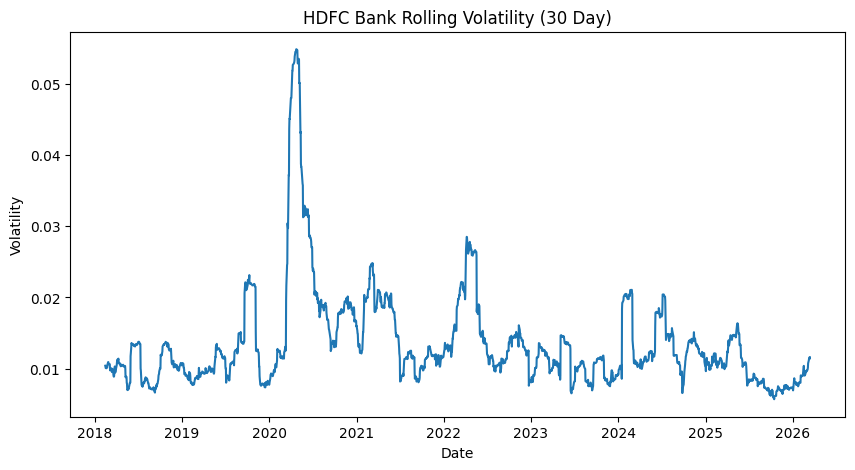

In [ ]:
data["rolling_vol"] = data["log_return"].rolling(30).std()

plt.figure(figsize=(10,5))
plt.plot(data["rolling_vol"])

plt.title("HDFC Bank Rolling Volatility (30 Day)")
plt.xlabel("Date")
plt.ylabel("Volatility")

plt.show()

## Maximum Drawdown

Maximum drawdown measures the largest decline from a peak in the stock price.
It indicates the worst possible loss an investor could have experienced.

Maximum Drawdown: -0.4105497669425776


Text(0.5, 1.0, 'Maximum Drawdown')

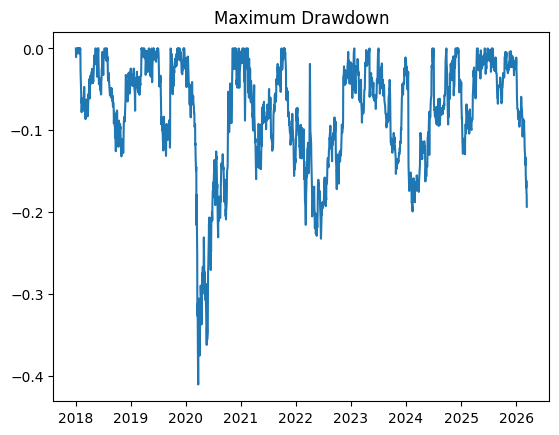

In [ ]:
cum_returns = (1 + data["simple_return"]).cumprod()

rolling_max = cum_returns.cummax()

drawdown = cum_returns / rolling_max - 1

max_drawdown = drawdown.min()

print("Maximum Drawdown:", max_drawdown)
plt.plot(drawdown)
plt.title("Maximum Drawdown")

## Cumulative Return

Cumulative return shows the total growth of an investment in HDFC Bank over time.

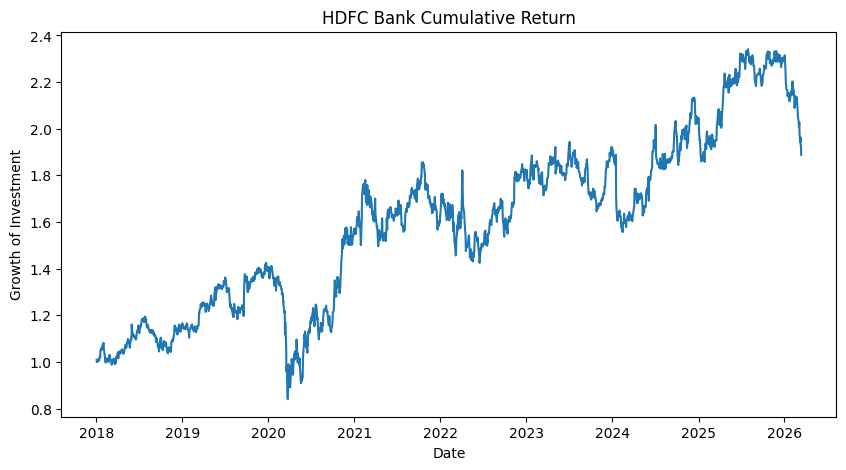

In [ ]:
cum_returns = (1 + data["simple_return"]).cumprod()

plt.figure(figsize=(10,5))
plt.plot(cum_returns)

plt.title("HDFC Bank Cumulative Return")
plt.xlabel("Date")
plt.ylabel("Growth of Investment")

plt.show()